# 04. GGNN

This notebook trains a `GGNN` node-classification model on the sampled wash-trading graph.

Included by default:

- stratified train/val/test split
- train-time early stopping
- threshold tuning on validation set
- rich test metrics
- loss curves, ROC curve, PR curve, confusion matrix, score histogram, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- node features are used without explicit graph-stat columns


In [19]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from graph_model_utils import (
    build_graph_dataset,
    classification_report_df,
    evaluate_probabilities,
    find_best_threshold,
    get_model,
    plot_evaluation_dashboard,
    plot_training_history,
    predict_probabilities,
    set_seed,
    train_model,
)


In [20]:
MODEL_NAME = "ggnn"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
HIDDEN_DIM = 64
DROPOUT = 0.2
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
PATIENCE = 15
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [21]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,8,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 8


In [22]:
model = get_model(
    model_name=MODEL_NAME,
    in_dim=data["features"].shape[1],
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", parameter_count)


GGNNModel(
  (input_proj): Linear(in_features=8, out_features=64, bias=True)
  (ggnn): GatedGraphConv(
    (linears): ModuleList(
      (0): Linear(in_features=64, out_features=64, bias=True)
    )
    (gru): GRUCell(64, 64)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Trainable parameters: 29826


,epoch,train_loss,val_loss,val_threshold,train_Threshold,train_PR-AUC,train_ROC-AUC,train_F1,train_Precision,train_Recall,...,val_Brier-Score,val_Log-Loss,val_Accuracy,val_TP,val_FP,val_TN,val_FN,val_TopK,val_Precision@K,val_Recall@K
25,26,0.420497,0.414715,0.600,0.600,0.682986,0.943276,0.670502,0.570285,0.813452,...,0.101432,0.362416,0.908667,133,101,1230,36,169,0.615385,0.615385
26,27,0.413585,0.408977,0.600,0.600,0.683411,0.943809,0.664256,0.560105,0.815990,...,0.101880,0.362907,0.908000,135,104,1227,34,169,0.621302,0.621302
27,28,0.409996,0.401720,0.600,0.600,0.682719,0.943657,0.663934,0.556701,0.822335,...,0.098564,0.353212,0.908000,136,105,1226,33,169,0.609467,0.609467
28,29,0.402906,0.395335,0.625,0.625,0.681643,0.943933,0.670846,0.570160,0.814721,...,0.098926,0.353255,0.909333,134,101,1230,35,169,0.603550,0.603550
29,30,0.396645,0.388444,0.625,0.625,0.681815,0.944103,0.664271,0.557759,0.821066,...,0.098619,0.351104,0.908667,136,104,1227,33,169,0.597633,0.597633


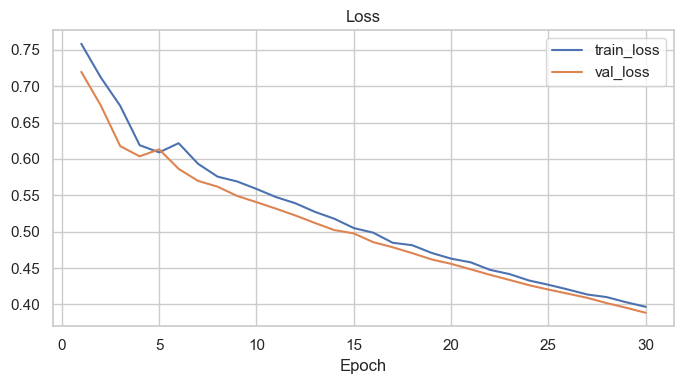

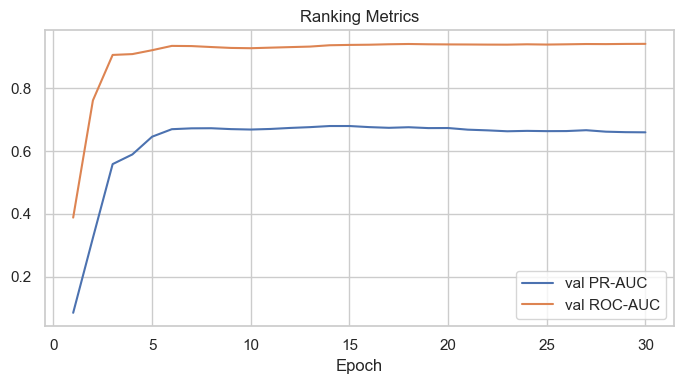

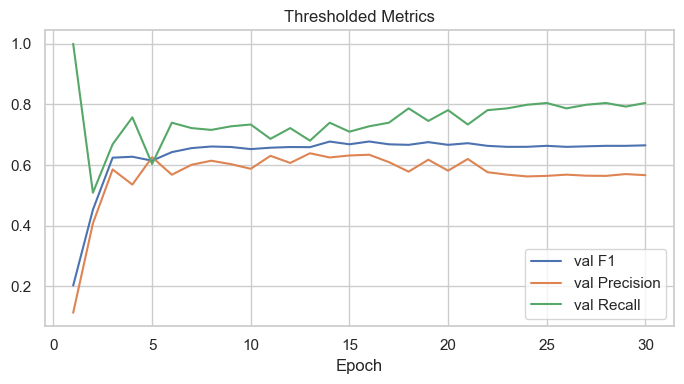

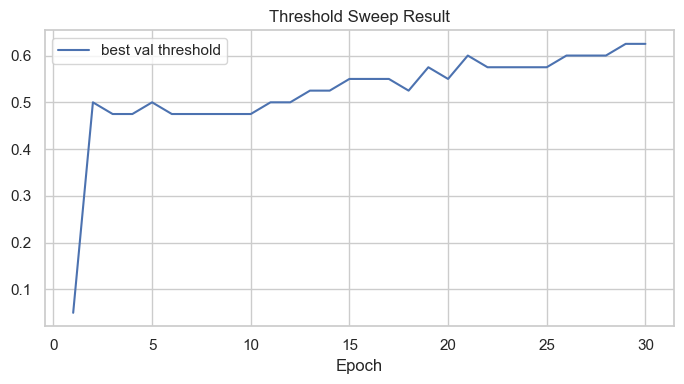

In [23]:
best_model, history_df = train_model(
    model=model,
    data=data,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(history_df.tail())
plot_training_history(history_df)


In [24]:
val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
best_threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)

test_true, test_prob = predict_probabilities(best_model, data, "test_mask")
test_metrics = evaluate_probabilities(test_true, test_prob, best_threshold)

metrics_df = pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.550000
PR-AUC,0.691440
ROC-AUC,0.938952
F1,0.668555
Precision,0.641304
Recall,0.698225
Specificity,0.950413
NPV,0.961246
Balanced-Accuracy,0.824319
MCC,0.625170


In [25]:
report_df = classification_report_df(test_true, test_prob, best_threshold)
display(report_df)


,precision,recall,f1-score,support
0,0.961246,0.950413,0.955799,1331.000
1,0.641304,0.698225,0.668555,169.000
accuracy,0.922000,0.922000,0.922000,0.922
macro avg,0.801275,0.824319,0.812177,1500.000
weighted avg,0.925199,0.922000,0.923436,1500.000


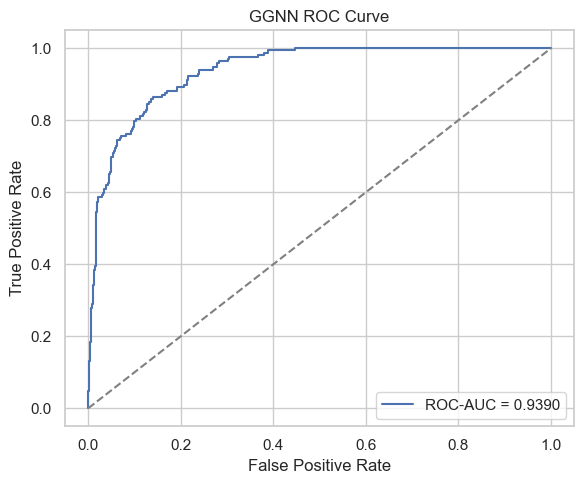

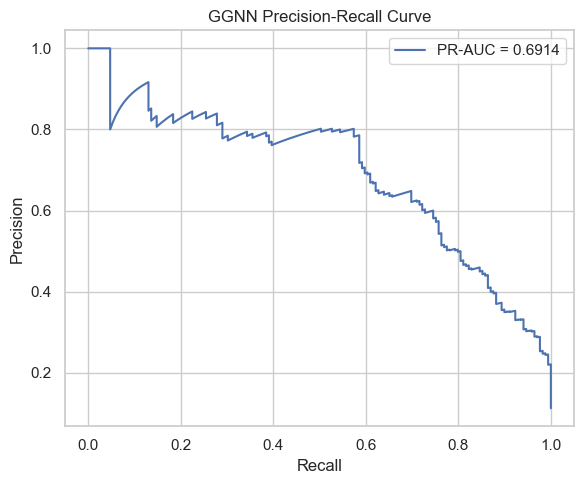

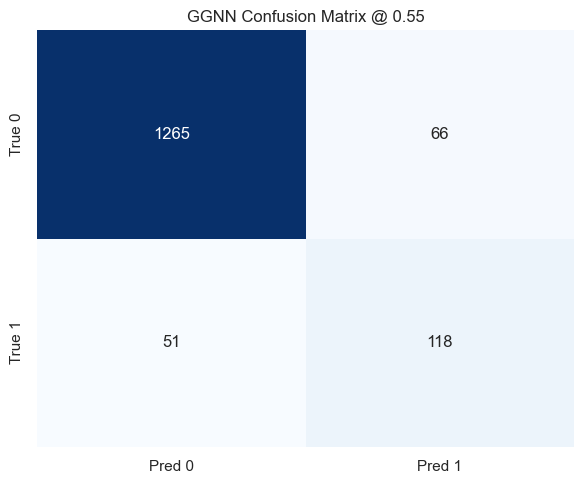

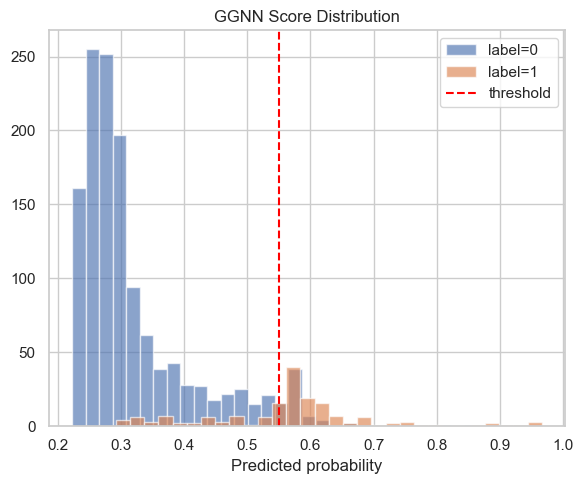

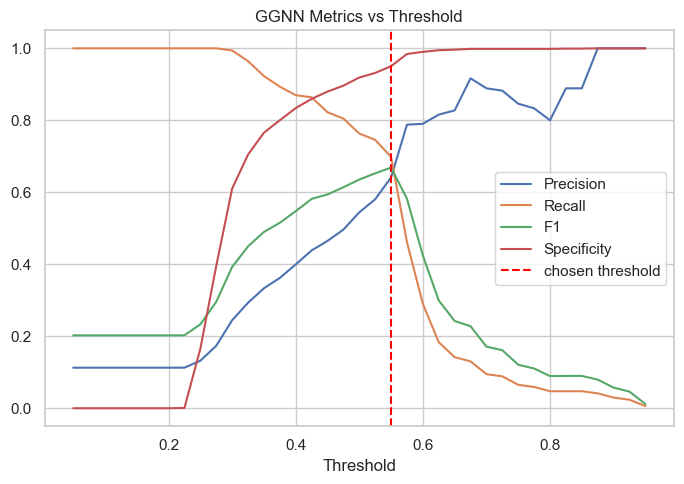

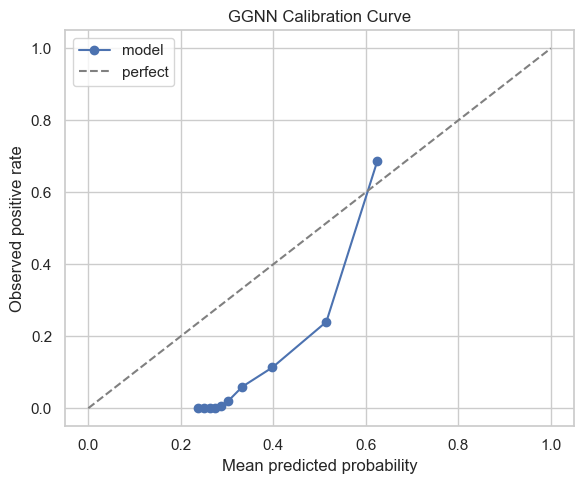

In [26]:
plot_evaluation_dashboard(
    y_true=test_true,
    y_prob=test_prob,
    threshold=best_threshold,
    title_prefix=MODEL_NAME.upper(),
)


In [ ]:
test_node_rows = data["nodes_df"].loc[data["test_mask"].detach().cpu().numpy()].copy()
test_node_rows["predicted_probability"] = test_prob
test_node_rows["predicted_label"] = (test_prob >= best_threshold).astype(int)

suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2046,258361,1,0.966066,1,2,0
1539,204115,1,0.945370,1,1,1
2478,308537,1,0.943677,1,1,1
1834,235606,1,0.927951,1,5,5
2754,343737,1,0.913779,1,2,1
1664,217839,1,0.891664,1,11,8
2209,276703,1,0.876703,1,1,0
2732,341302,1,0.874706,1,4,2
2315,288808,0,0.864768,1,67,2
124,16510,0,0.813540,1,480,82


: 

## Notes

Keep the reported `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing models.
The threshold comes from validation data and is reused on the test split.
